# Load packages

In [ ]:
library(circlize)
library(ComplexHeatmap)
library(dplyr)

circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))


载入需要的程序包：grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive

In [15]:
library(janitor)


载入程序包：‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




# Read in data

In [ ]:
sample_anno.df.sub <- read.csv('./data/TCGA.sample_anno.add_score.csv', sep=',', row.names = 1, check.names = F, stringsAsFactors = F)

### h1

In [10]:
col_to_rank <- 'GPX2_top150Gene_Signature'

In [11]:
sample_order <- rownames(sample_anno.df.sub[order(sample_anno.df.sub[[col_to_rank]], decreasing = TRUE), ])

- **打分信息**

In [ ]:
col_save = c(
    col_to_rank,
    'ImmuneScore_estimate',
    'Immune cytolytic activity (CYT) PMID: 25594174', 'Tumor Inflammation Signature (TIS) PMID: 29929551', 'T cell–inflamed GEP PMID: 28650338', 
    'preliminary IFN-γ signature PMID: 28650338', '13 gene signature PMID: 33782030'
)

sample_anno.df.sub.h1 = na.omit(sample_anno.df.sub[sample_order, col_save])
sample_anno.df.sub.h1 %>% dim()

[1] 509   7

In [ ]:

sample_anno.df.sub.h1 <- sample_anno.df.sub.h1 %>%
    clean_names()

In [17]:
# scaled
indata1 = scale(sample_anno.df.sub.h1)

dim(indata1)
print(colMeans(indata1)[1])
print(apply(indata1, 2, sd)[1])

indata1 = t(indata1[sample_order,])

[1] 509   7

gpx2_top150gene_signature 
            -3.112823e-16 
gpx2_top150gene_signature 
                        1 


In [ ]:

col_save = c(
            'Smoking',
            'Classical', 'Atypical','Mesenchymal', 'Basal'
              )  

sample_anno.df.sub.h2 = na.omit(sample_anno.df.sub[sample_order, col_save])

col = list(
           Smoking = c('Yes'='#ae445a','No'='white'),
           
           Classical = c('Yes'='black','No'='white'),
           Mesenchymal = c('Yes'='black','No'='white'),
           Atypical = c('Yes'='black','No'='white'),
           Basal = c('Yes'='black','No'='white')
        )

top_annotation = HeatmapAnnotation(df = sample_anno.df.sub.h2,
        col = col,
        na_col = "grey95",
        annotation_name_side='right',
        annotation_name_gp = gpar(fontsize = 8)
    )    

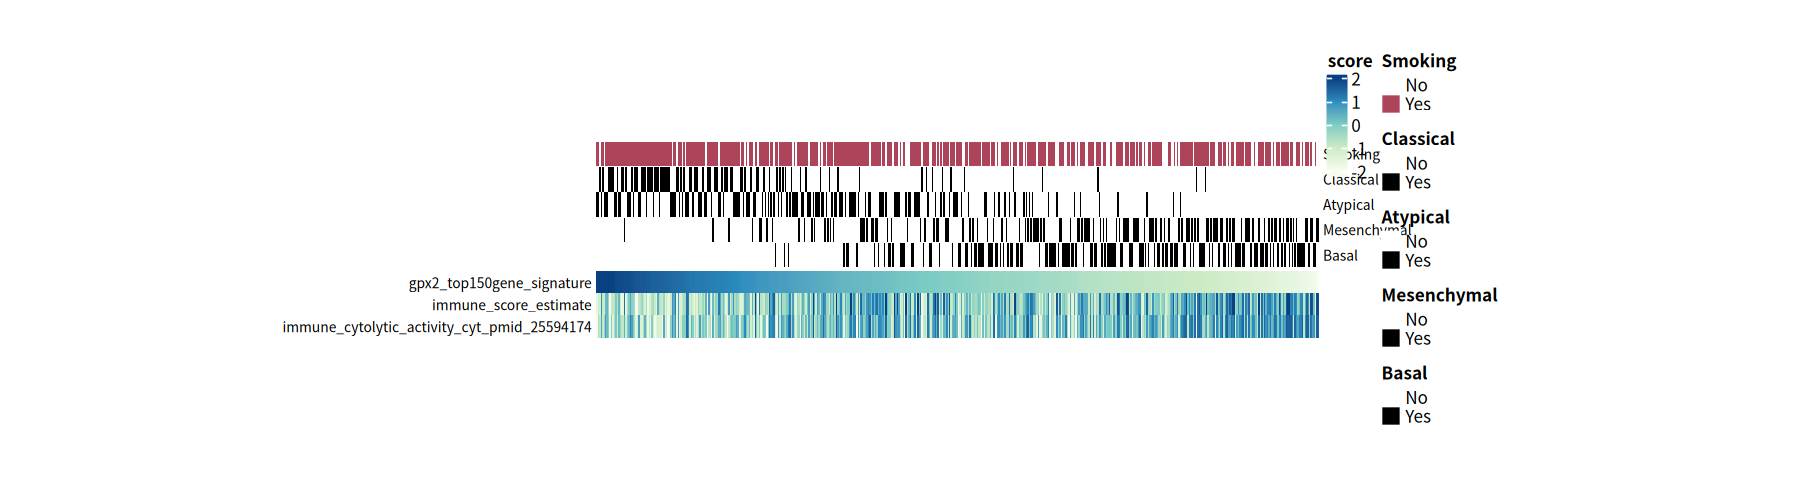

In [ ]:
# plot
options(repr.plot.width=15, repr.plot.height=4)

heatmap.BlWtRd <- c("#F7FCF0", "#CCEBC5", "#7BCCC4", "#2B8CBE", "#084081")

col_expr <- colorRamp2(c(-2, -1, 0, 1, 2), heatmap.BlWtRd) 

h1 = Heatmap(indata1[c('gpx2_top150gene_signature', 'immune_score_estimate', 'immune_cytolytic_activity_cyt_pmid_25594174'), rownames(sample_anno.df.sub.h2)], 
        col=col_expr,
        name = paste('score'), 
        cluster_rows       = F,
        cluster_columns    = F, 
        row_dend_reorder   = F,
        column_dend_reorder = T,
        show_row_names     = T,
        show_column_names  = F,
        row_names_side     = "left", 
        cluster_row_slices = F, 
         top_annotation    = top_annotation,
        row_names_gp       = gpar(fontsize = 8),
        column_names_gp       = gpar(fontsize = 10), 
        width              = ncol(indata1) * unit(0.3, "mm"),
        height             = nrow(indata1) * unit(2, "mm")
       )

print(h1)

## h2

In [ ]:
exprs = read.csv('./data/TCGA-allHNSC.txt', sep='\t', row.name=1, check.names = F, stringsAsFactors = F) 

In [ ]:

GPX2_up_DEGs = data.frame(names = c(
    'EPCAM', 'ALDH1A1',
    'PGD',
    'NQO1', 
    'ABCC5',
    'ADH7','AKR1C1','AKR1C2','AKR1C3',
    'GCLM','GPX2',
    'GSTM3',
    'NTS','SOX2',
    'TP63','UPK1B'
), cluster = 'GPX2_up_DEGs')
GPX2_down_DEGs = data.frame(names = c(
    'IRF1', 'IFIT3',
    'B2M','CCL5','CD74',#'CRIP2',
    'CXCL10','HLA-DPA1','HLA-DPB1','HLA-DRA','HLA-DRB1',
    'HLA-DRB6','HLA-E','IFI6','IFITM1','IFITM3',
    'TRIM22'
), cluster = 'GPX2_down_DEGs')

gene_anno = rbind(GPX2_up_DEGs,GPX2_down_DEGs)

table(gene_anno$cluster)
gene_anno %>% head(2)


GPX2_down_DEGs   GPX2_up_DEGs 
            16             16 

,names,cluster
,<chr>,<chr>
1,EPCAM,GPX2_up_DEGs
2,ALDH1A1,GPX2_up_DEGs


In [ ]:
exprs.sub = exprs[, which(colnames(exprs) %in% rownames(sample_anno.df.sub.h2))]

In [ ]:
gene_anno = gene_anno[gene_anno$names %in% rownames(exprs.sub),]

In [ ]:
indata2 = exprs.sub[gene_anno$names, ]
indata2 = t(scale(t(indata2)))  

print(rowMeans(indata2)[1])
print(apply(indata2, 1, sd)[1])   
print(colMeans(indata2)[1])
print(apply(indata2, 2, sd)[1])  

       EPCAM 
-1.41092e-16 
EPCAM 
    1 
TCGA-D6-A4ZB-01A-11R-A24Z-07 
                  -0.1246302 
TCGA-D6-A4ZB-01A-11R-A24Z-07 
                   0.9607021 


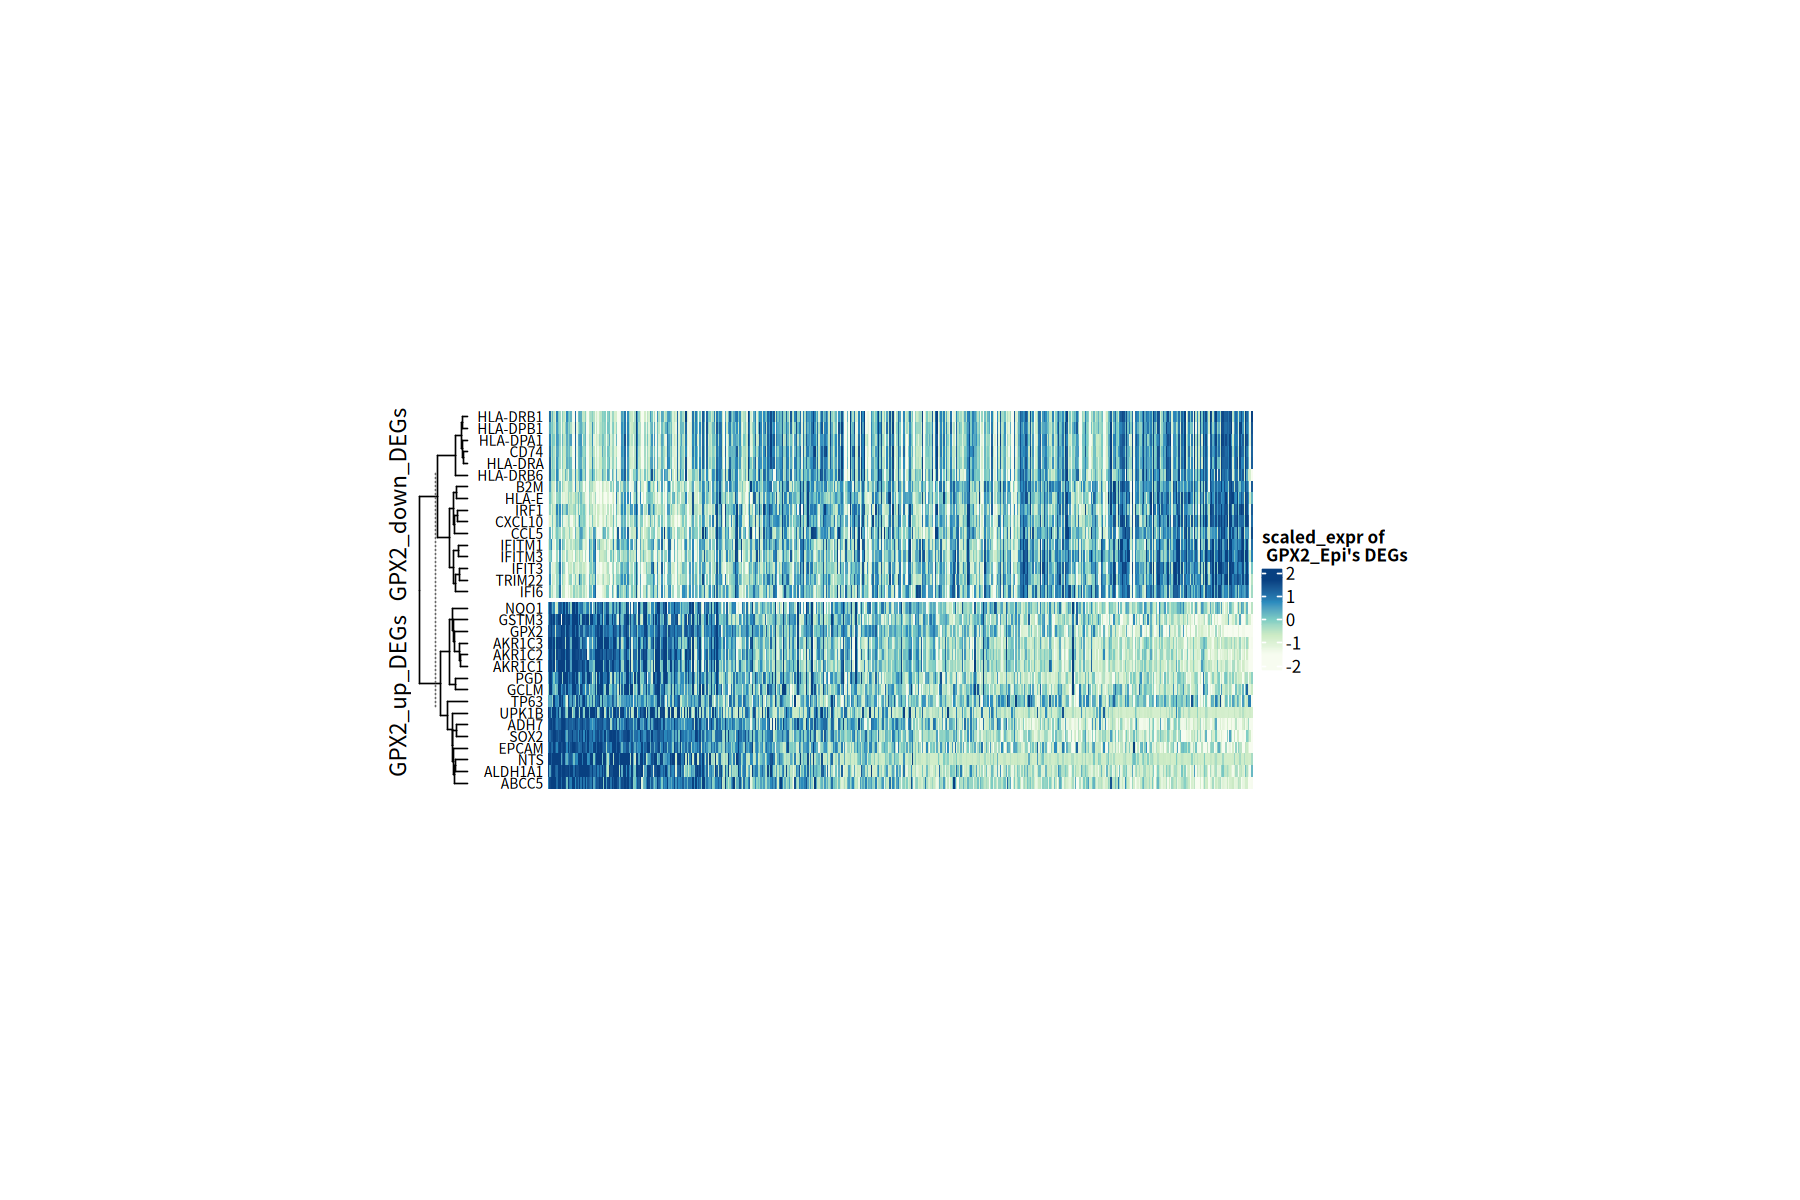

In [ ]:
# plot
options(repr.plot.width=15, repr.plot.height=10)

heatmap.BlWtRd <- c("#F7FCF0", "#CCEBC5", "#7BCCC4", "#2B8CBE", "#084081")

col_expr <- colorRamp2(c(quantile(indata2, 0.05),quantile(indata2, 0.25),0,quantile(indata2, 0.75),quantile(indata2, 0.95)), heatmap.BlWtRd)

h2 = Heatmap(indata2[gene_anno$names, rownames(sample_anno.df.sub.h2)], 
        col=col_expr,
        name = "scaled_expr of \n GPX2_Epi's DEGs", 
        cluster_rows       = T,
        cluster_columns    = F, 
        clustering_method_rows = "ward.D2",
        row_dend_reorder   = T, 
        show_row_names     = T, 
        show_column_names  = F,
        row_names_side     = "left", 
        row_names_gp       = gpar(fontsize = 8), 
        column_names_gp       = gpar(fontsize = 10),
        row_split = gene_anno$cluster, column_gap = unit(2, "mm"),
        width              = ncol(indata2) * unit(0.3, "mm"),
        height             = nrow(indata2) * unit(2.5, "mm")
       )

print(h2)

## merge h1/h2

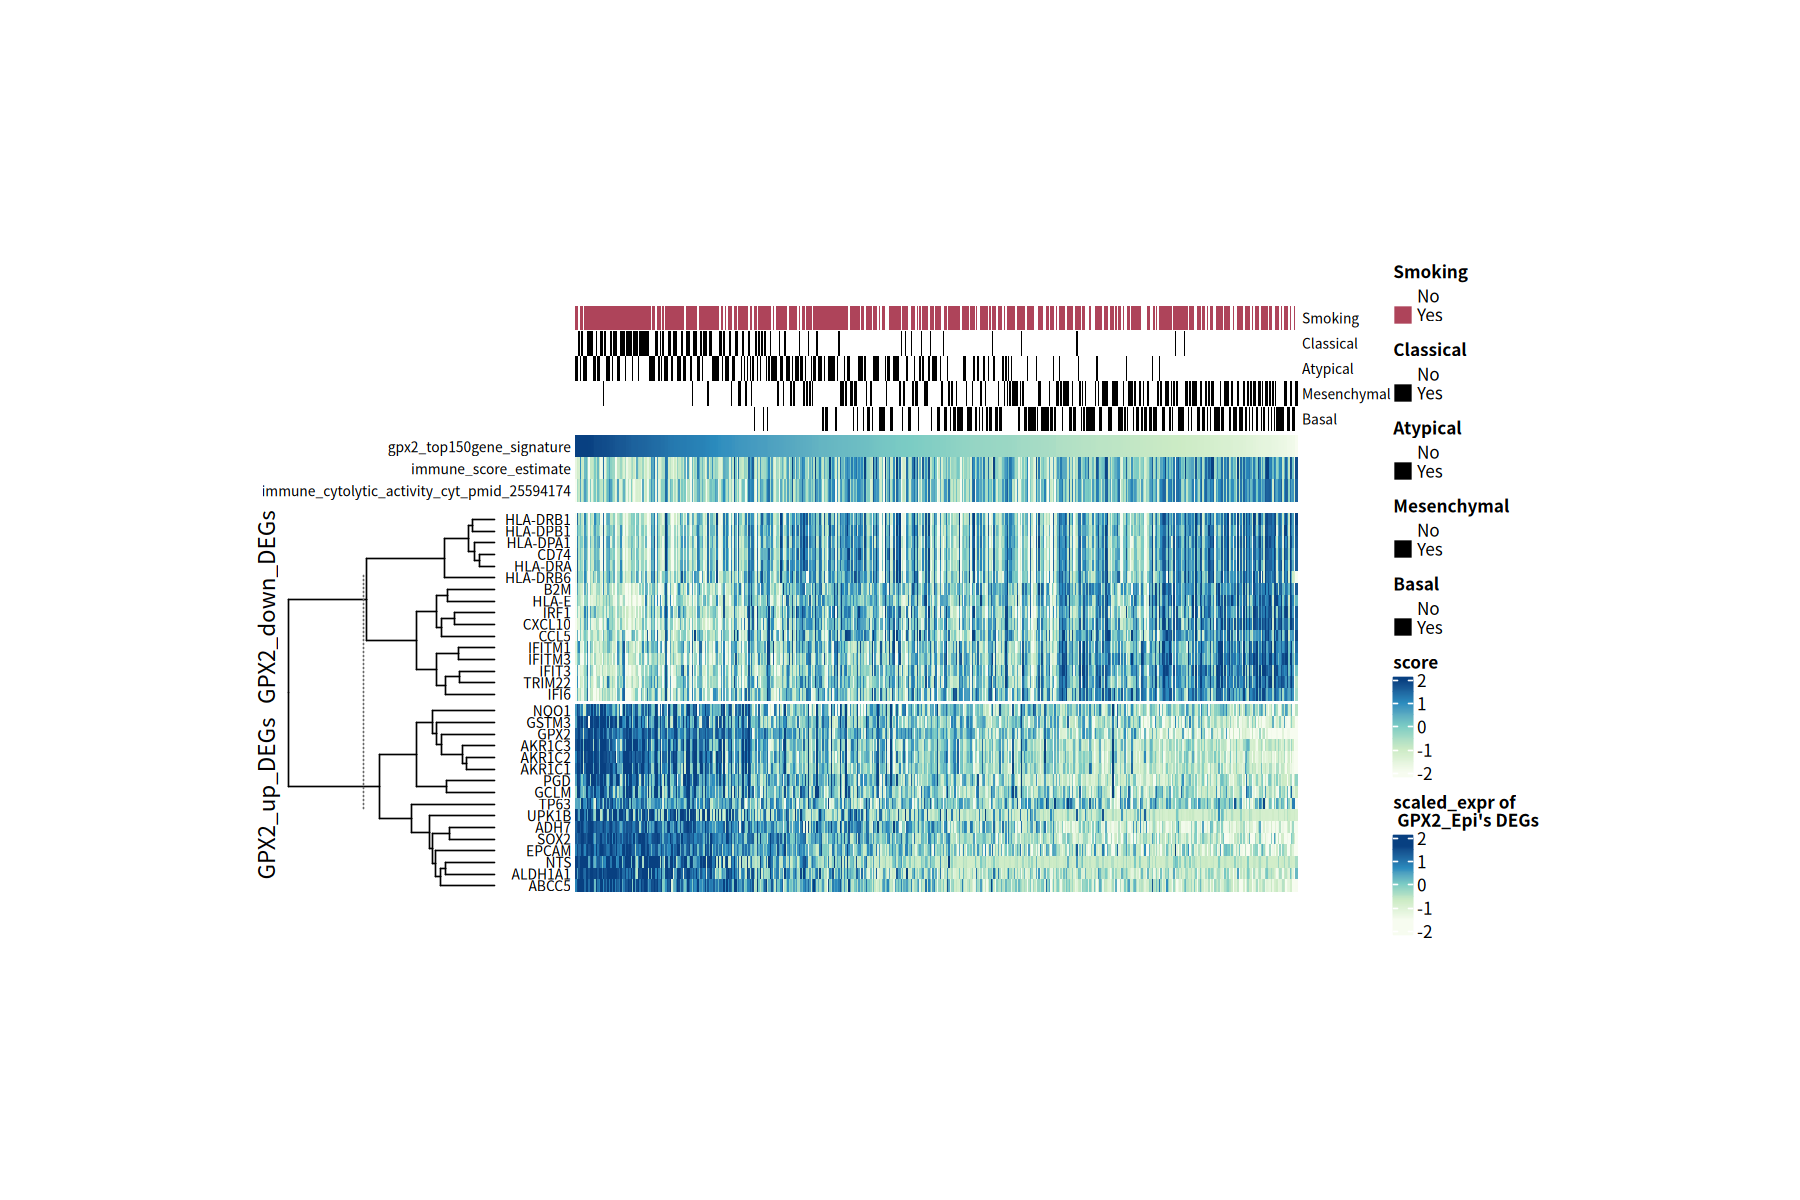

In [36]:
options(repr.plot.width=15, repr.plot.height=10)
h1 %v% h2

## save

In [ ]:
save_path = './figures/MergeHeatmap.TCGA.sort_GPX2_signature.pdf'

In [42]:
pdf(file = save_path, width = 15,height = 10)
h1 %v% h2
dev.off()

agg_record_769500319 
                   2